In [1]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))
import importlib
import utils 
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_template_from_geneset
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
ROOT_DIR

PosixPath('/Users/czyjtu/dev/prompt2avatar')

# Prepare data for trainig 

In [4]:
import utils.dataset 
import models.mlp
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA 
GENESET = "easy"
DATASET_NAME = 'easy_geneset_embeddings'
FEATURES = "arcface-r100"
DATASET_DIR = DATA_DIR / DATASET_NAME
EXPERIMENT_DIR = ROOT_DIR / 'experiments' / DATASET_NAME

TEST_DATASET_DIR = DATA_DIR / 'prison_sample_embeddings'

geneset = ProcessedDataset(DATASET_DIR)
images = geneset.alligned_images
X, Y = get_raw_dataset(GENESET, FEATURES)
X_train, X_test, Y_train, Y_test, images_train, images_test = train_test_split(X, Y, images, test_size=0.1, random_state=42)
scaler_x = MinMaxScaler()
scaler_x.fit(X_train)
X_train_sc = scaler_x.transform(X_train)
X_test_sc = scaler_x.transform(X_test)
print(f"shape of dataset: {X.shape}, {Y.shape}")

real_dataset = ProcessedDataset(TEST_DATASET_DIR)
real_images = real_dataset.alligned_images
Y_real = real_dataset.model2normalized_embeddings[FEATURES]
print(f"shape of real dataset: {Y_real.shape}")

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 7/7 [00:00<00:00, 60.69it/s]


shape of dataset: (30332, 13), (30332, 512)


100%|██████████| 9/9 [00:00<00:00, 1035.66it/s]

shape of real dataset: (1000, 512)


# Models

In [5]:
pd.set_option('display.max_rows', None)

def error_per_features(Y_test, Y_pred, gene_names):
    # comput rmse per feature in Y
    rmse_per_feature = np.sqrt(np.mean((Y_test - Y_pred)**2, axis=0))
    std_per_feature = np.std(Y_test, axis=0)
    tuples =  list(zip(range(len(gene_names)), sorted(gene_names), rmse_per_feature, std_per_feature))
    tuples = sorted(tuples, key=lambda x: x[2], reverse=True)
    df = pd.DataFrame(tuples, columns=["index", "gene", "rmse", "std"])
    df.set_index("index", inplace=True)
    # dipaly all rows of this df 
    return df

## XGboost

In [7]:
# train xgboost model
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from wandb.integration.xgboost import WandbCallback
import wandb 

xgb_model_path = EXPERIMENT_DIR / 'xgb_model.pkl'
if xgb_model_path.exists():
    with open(xgb_model_path, 'rb') as f:
        model = pickle.load(f)
else:
    xgb_model_path.parent.mkdir(parents=True, exist_ok=True)
    evalset = [(Y_train, X_train), (Y_test, X_test)]
    model = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 1, learning_rate = 0.1,
                    max_depth = 8, n_estimators = 1000)
    
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["xgboost", GENESET], group="xgboost" + GENESET
    ) as wandb_run:
        model.fit(Y_train, X_train, eval_metric='rmse', eval_set=evalset, verbose=True, callbacks=[WandbCallback(log_model=True)])
        with open(xgb_model_path, 'wb') as f:
            pickle.dump(model, f)

X_pred = model.predict(Y_test)
rmse = np.sqrt(mean_squared_error(X_test, X_pred))
r2 = r2_score(X_test, X_pred, multioutput='uniform_average')
mae = mean_absolute_error(X_test, X_pred, multioutput='uniform_average')
print("RMSE: %f  R2: %f  MAE:  %f" % (rmse, r2, mae))

RMSE: 123.442719  R2: -36.965306  MAE:  113.116402


In [9]:
save_predicitons(X_pred, scaler_x, EXPERIMENT_DIR / 'predicted_dnas_xgb', GENESET)

100%|██████████| 7/7 [00:00<00:00, 61.80it/s]


In [10]:
X_real_pred = model.predict(Y_real)
save_predicitons(X_real_pred, scaler_x, EXPERIMENT_DIR / 'predicted_real_dnas_xgb', GENESET)


100%|██████████| 7/7 [00:00<00:00, 54.54it/s]


## Random Forest

In [11]:
# run random forest regressor 
from sklearn.ensemble import RandomForestRegressor

random_forest_path = EXPERIMENT_DIR / 'random_forest_model.pkl'
if random_forest_path.exists():
    with open(random_forest_path, 'rb') as f:
        model = pickle.load(f)
else:
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["decision_trees", GENESET], group="decision_trees" + GENESET
    ) as wandb_run:
        random_forest_path.parent.mkdir(parents=True, exist_ok=True)
        model = RandomForestRegressor(n_estimators=500, max_depth=8) 
        model.fit(Y_train, X_train)
        with open(random_forest_path, 'wb') as f:
            pickle.dump(model, f)
        
        wandb.sklearn.plot_regressor(model, Y_train, Y_test, X_train, X_test, model_name="RandomForestRegressor")
        
X_pred = model.predict(Y_test)
rmse = np.sqrt(mean_squared_error(X_test, X_pred))
r2 = r2_score(X_test, X_pred, multioutput='uniform_average')
mae = mean_absolute_error(X_test, X_pred, multioutput='uniform_average')
print("RMSE: %f  R2: %f  MAE:  %f" % (rmse, r2, mae))
save_predicitons(X_pred, scaler_x, EXPERIMENT_DIR / 'predicted_dnas_rf', GENESET)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: czyjtu. Use `wandb login --relogin` to force relogin


Traceback (most recent call last):
  File "/var/folders/j2/83k2pfk133n_vkpjy9xj72c00000gn/T/ipykernel_13455/2062205821.py", line 15, in <module>
    model.fit(Y_train, X_train)
  File "/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/sklearn/base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py", line 489, in fit
    trees = Parallel(
  File "/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/sklearn/utils/parallel.py", line 67, in __call__
    return super().__call__(iterable_with_config)
  File "/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/joblib/parallel.py", line 1863, in __call__
    return output if self.return_generator else list(output)
  File "/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/joblib/parallel.py", line 1792, in _get_sequential_output
    res = func(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:
X_real_pred = model.predict(Y_real)
save_predicitons(X_real_pred, scaler_x, EXPERIMENT_DIR / 'predicted_real_dnas_rf', GENESET)

## MLP

In [12]:
import torch as th 
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pytorch_lightning as pl
import pytorch_lightning.callbacks as pl_callbacks
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import EarlyStopping
import importlib
import models.callbacks as callbacks
importlib.reload(callbacks)
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import torch 
from models.callbacks import SimpleRegressionCallbacks
from models.diffusion.ddpm import ConditionalDDPM, SimpleCondNet, ConditionalNetworkConfig
import torch.utils.data 
import wandb 

class DNARegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressor, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    

class MLP(pl.LightningModule):
    def __init__(self, model: nn.Module):
        super(MLP, self).__init__()
        self.model = model 
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss


X_th = torch.tensor(X_train).float()
Y_th = torch.tensor(Y_train).float()

train_dataset = torch.utils.data.TensorDataset(Y_th, X_th)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(torch.tensor(Y_test).float(), torch.tensor(X_test).float())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)


# Initialize the model
input_dim = Y_train.shape[1]
output_dim = X_train.shape[1]

mlp_model_path = EXPERIMENT_DIR / 'mlp_model.ckpt'
if  mlp_model_path.exists():
    # model_raw = DNARegressor(input_dim, output_dim, [256])
    model = MLP.load_from_checkpoint(mlp_model_path)
else:
    mlp_model_path.parent.mkdir(parents=True, exist_ok=True)
    model_raw = DNARegressor(input_dim, output_dim, [256])
    model = MLP(model_raw)

    import wandb 

    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["mlp", GENESET], group="mlp" + GENESET
        ) as wandb_run:
        # Initialize Wandb logger
        wandb_logger = WandbLogger(project='prompt2avatar', entity="czyjtu", log_model=True)

        # Initialize Lightning Trainer with checkpointing and logging
        checkpoint_callback = pl_callbacks.ModelCheckpoint(
            monitor='val_loss',
            dirpath='checkpoints',
            filename='best_model',
            save_top_k=1,
            mode='min'
        )
        callback = SimpleRegressionCallbacks(
                    torch.tensor(test_images).float(),
                    torch.tensor(X_test).float(), 
                    torch.tensor(Y_test).float(), 
                    scaler_x
                )

        trainer = pl.Trainer(
            max_epochs=30,
            logger=wandb_logger,
            callbacks=[checkpoint_callback, EarlyStopping(monitor="val_loss", mode="min"), callback],
            default_root_dir=ROOT_DIR / "training_logs",
            enable_checkpointing=True,
        )  # You can adjust max_epochs and other parameters

        # Train the model
        trainer.fit(model, train_loader, test_loader)
    
    best_model_path = checkpoint_callback.best_model_path
    # move this file to the experiment directory
    best_model_path = Path(best_model_path)
    best_model_path.rename(mlp_model_path)

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [14]:
model.eval().to("cpu")
save_predicitons(model.forward(th.tensor(Y_test).float()).detach().numpy(), scaler_x, EXPERIMENT_DIR / 'predicted_dnas_mlp', GENESET) 

100%|██████████| 7/7 [00:00<00:00, 77.71it/s]


In [15]:
model.eval().to("cpu")
Y_real_pred = model.forward(th.tensor(Y_real).float()).detach().numpy()
save_predicitons(X_real_pred, scaler_x, EXPERIMENT_DIR / 'predicted_real_dnas_mlp', GENESET)

100%|██████████| 7/7 [00:00<00:00, 91.68it/s]


: 

# Ck vs Ck Face similarities

In [6]:
def get_cosine_similarity_matrix(X, X_pred):
    X = X / np.linalg.norm(X, axis=1)[:, None]
    X_pred = X_pred / np.linalg.norm(X_pred, axis=1)[:, None]
    return X @ X_pred.T

def display_random_pair(images, pred_images, i):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(images[i])
    ax[1].imshow(pred_images[i])
    plt.show()

mlp_pred_dataset = ProcessedDataset(EXPERIMENT_DIR / 'predicted_faces_mlp_embeddings')
indicies_with_detected_faces = [int(p.split('_')[-1].split('.')[0]) for p in mlp_pred_dataset.paths]
test_images_with_faces = [test_images[i] for i in indicies_with_detected_faces]

100%|██████████| 1/1 [00:00<00:00, 431.73it/s]


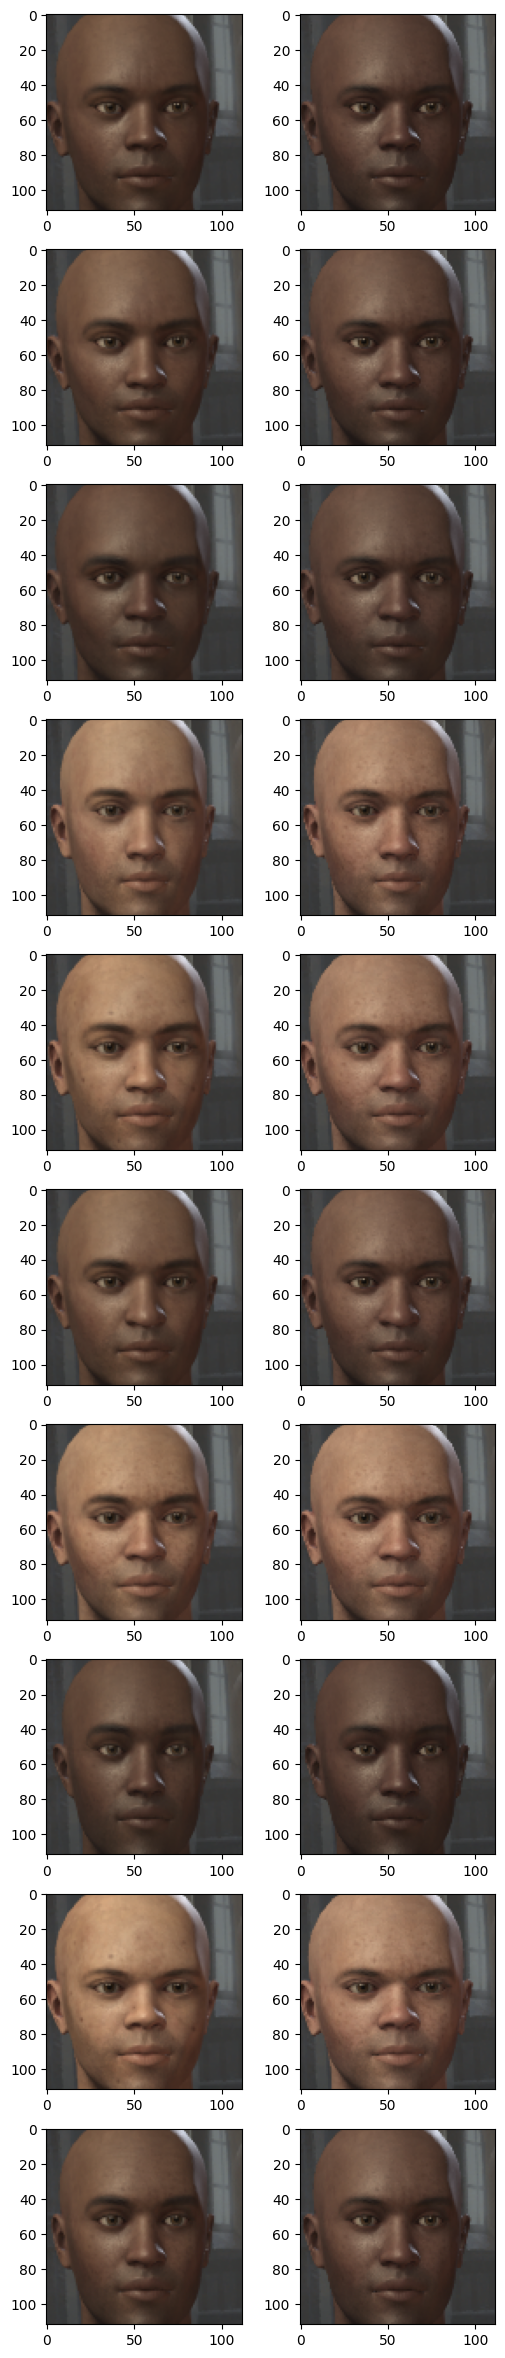

In [16]:
# get grid of imagse 10 x 2 

fig, axs = plt.subplots(10, 2, figsize=(6, 30))
for j, i in enumerate(range(100, 200, 10)):
    img = test_images_with_faces[i]
    pred_img = mlp_pred_dataset.alligned_images[i]
    axs[j, 0].imshow(img)
    axs[j, 1].imshow(pred_img)
plt.show()

# for i in range(100, 200, 10): display_random_pair(test_images_with_faces, mlp_pred_dataset.alligned_images, i)

In [9]:
X_pred.shape, X_real.shape

((3034, 512), (3034, 13))

In [10]:
# mean consine similarity between predicted and true embeddings
Y_pred_faces_features = mlp_pred_dataset.model2normalized_embeddings["arcface-r100"]
Y_real_faces_features = Y_test[indicies_with_detected_faces]
assert Y_pred_faces_features.shape == Y_real_faces_features.shape
cosine_sim = [x_true @ x_pred for x_true, x_pred in zip(Y_real_faces_features, Y_pred_faces_features)]
np.mean(cosine_sim)

0.9025792

# Real faces test

In [46]:
from thirdparty.recognition.arcface_torch.backbones import get_model # source:https://github.com/deepinsight/insightface/tree/master
import insightface
from insightface.utils import face_align
import torch as th 
import torchvision.transforms as VT
import numpy as np 
import warnings 
from tqdm import tqdm 
from pathlib import Path 
import matplotlib.pyplot as plt
from PIL import Image

def display_image(img: np.ndarray):
    plt.imshow(img)
    plt.axis("off")
    plt.show()

class FaceDetector:
    def __init__(self):
        self.insight_face_app = insightface.app.FaceAnalysis(name="antelopev2", allowed_modules=["detection"])
        self.insight_face_app.prepare(ctx_id = 0, det_thresh = 0.1)

    def __call__(self, img: np.ndarray):
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        face = self.insight_face_app.get(img)[0]
        aimg = face_align.norm_crop(img, landmark=face.kps, image_size=112)
        return aimg
    
def allign_faces(images: np.ndarray, detector: FaceDetector, labels: list[str]) -> tuple[np.ndarray["X", float], np.ndarray["y", str]]:
    def handle_no_face_detected(img: np.ndarray, i: int) -> np.ndarray | None:
        try:
            return detector(img)
        except IndexError:
            warnings.warn(f"No face detected in image {i}")
            return None
    
    alligned_images = [handle_no_face_detected(img, i) for i, img in tqdm(list(enumerate(images)))]
    filtered_images, filtered_labels = zip(*[(img, label) for img, label in zip(alligned_images, labels) if img is not None])    
    return np.array(filtered_images), np.array(filtered_labels)


def _load_insightface_model(weights_path: str) -> th.nn.Module:
    resnet_version = weights_path.split("_")[-1].split(".")[0]
    model = get_model(resnet_version)
    model.load_state_dict(th.load(weights_path, map_location=th.device('cpu')))
    model = model.eval()
    return model

In [47]:
REAL_IMG_PATHS = DATA_DIR / 'ck_faces_dataset' 
real_images_paths = [
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/brad_pit/006_aee8d88b.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/cersei_lannister/004_afbbdf8a.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/dr_house/002_3299cc32.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/freddie_mercury/002_19e97a8c.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/kanye_west/image.png",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/walter_white/002_7ff310e8.jpg"
]
    
real_images = [np.array(Image.open(p)) for p in real_images_paths]
detector = FaceDetector()
alligned_real_images, _ = allign_faces(real_images, detector, ["brad_pit", "cersei_lannister", "dr_house", "freddie_mercury", "kanye_west", "walter_white"])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


100%|██████████| 6/6 [00:00<00:00,  9.74it/s]


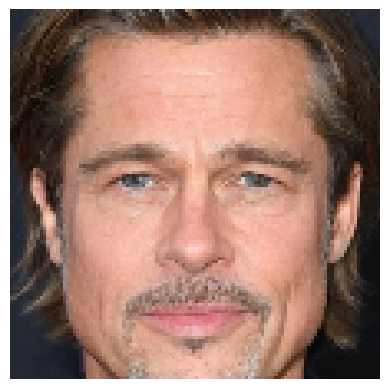

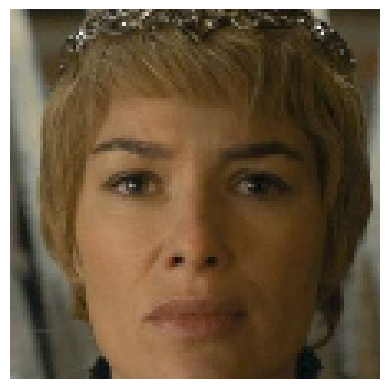

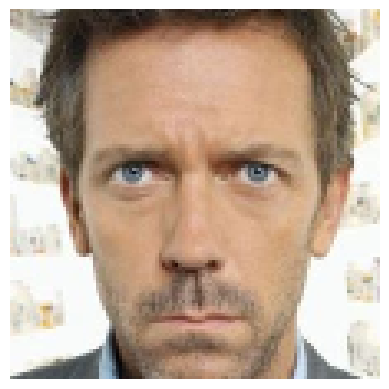

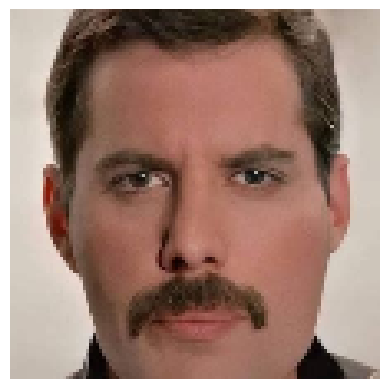

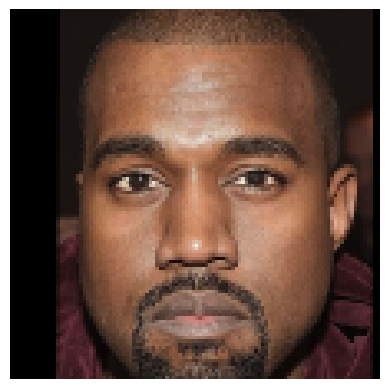

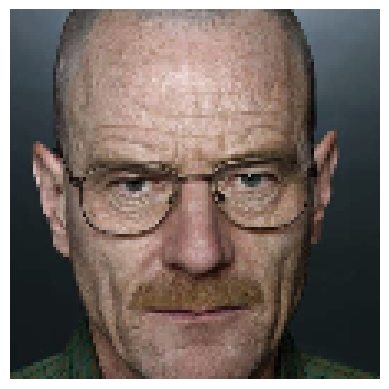

In [48]:
for img in alligned_real_images:
    display_image(img)

In [49]:
from utils.face_recognition import get_embeddings
from sklearn.preprocessing import normalize

In [55]:
RECOGNITION_MODEL_PATH = "/Users/czyjtu/dev/prompt2avatar/thirdparty/recognition/weights/arcface_r100.pth"
recognition_model = _load_insightface_model(RECOGNITION_MODEL_PATH)
real_image_embeddings = get_embeddings(alligned_real_images, recognition_model)
real_images_embeddings_normalized = normalize(real_image_embeddings)# / np.linalg.norm(real_image_embeddings, axis=1)[:, None]

100%|██████████| 1/1 [00:00<00:00, 10.88it/s]


In [56]:
real_genes_pred = model.forward(th.tensor(real_images_embeddings_normalized).float()).detach().numpy()
# clip to 0 - 1 range 
# real_genes_pred_clipped = np.clip(real_genes_pred, 0, 1)
save_predicitons(real_genes_pred, scaler_x, EXPERIMENT_DIR / 'real_faces_sample_mlp_embeddings', "easy")

100%|██████████| 1/1 [00:00<00:00, 27.89it/s]


In [57]:
real_genes_pred.min(), real_genes_pred.max()

(-0.114624165, 0.78775805)

In [58]:
X_pred.min(), X_pred.max()

(-0.003352243, 1.0217135)

### Brad pit 
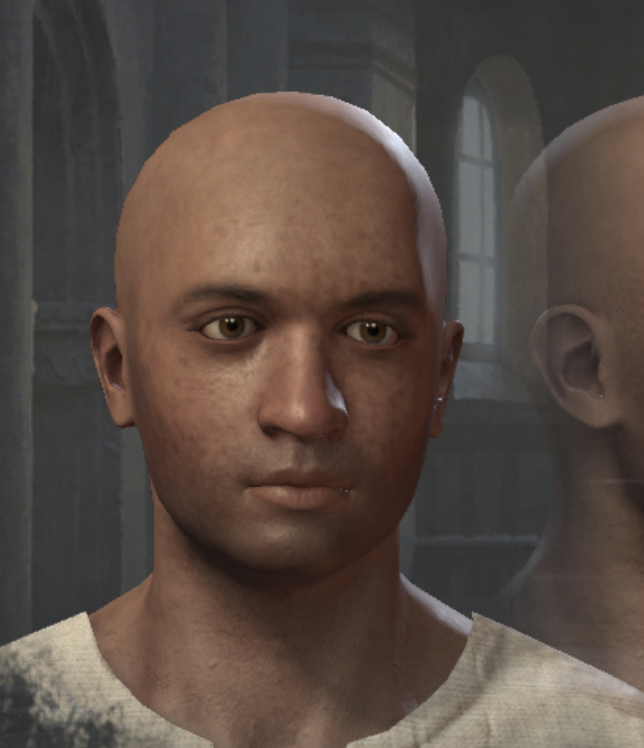

## dr.house 
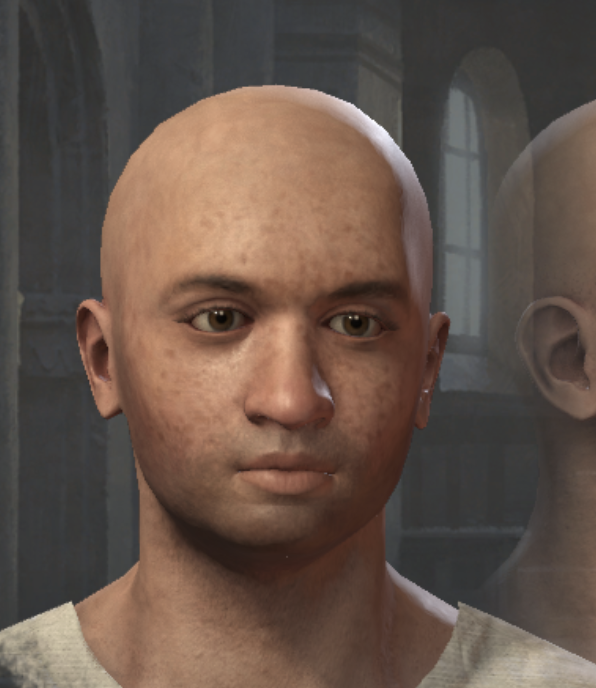

## freddie mercury 
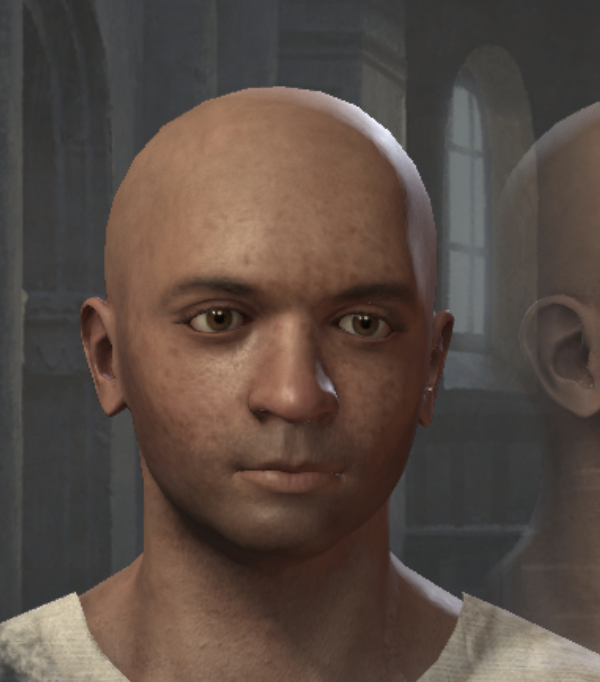

## kanye west
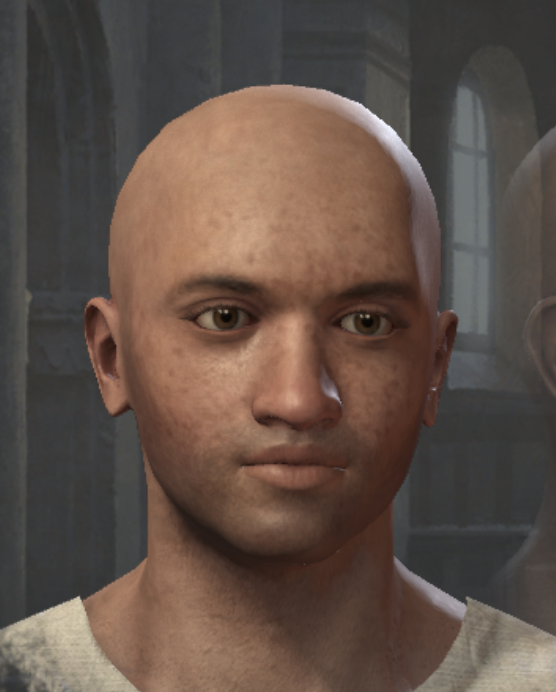

## walter white 
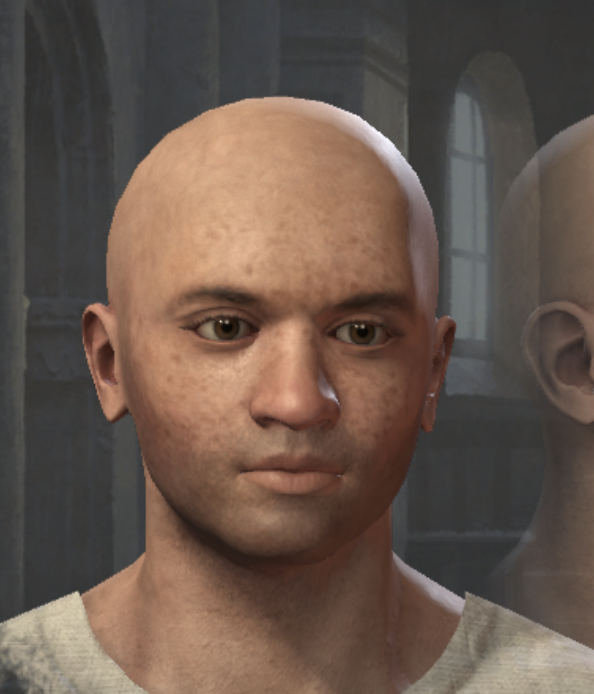

# brudnopis

### generate dnas with linear mutations 

In [25]:
dataset_dna_template

{'hair_color[0]': 93,
 'hair_color[1]': 220,
 'hair_color[2]': 93,
 'hair_color[3]': 220,
 'skin_color[0]': 131,
 'skin_color[1]': 154,
 'skin_color[2]': 131,
 'skin_color[3]': 154,
 'eye_color[0]': 87,
 'eye_color[1]': 218,
 'eye_color[2]': 87,
 'eye_color[3]': 218,
 'gene_chin_forward.chin_forward_pos': 127,
 'gene_chin_height.chin_height_pos': 127,
 'gene_chin_width.chin_width_pos': 127,
 'gene_eye_angle.eye_angle_pos': 126,
 'gene_eye_depth.eye_depth_pos': 139,
 'gene_eye_height.eye_height_pos': 115,
 'gene_eye_distance.eye_distance_pos': 132,
 'gene_eye_shut.eye_shut_pos': 131,
 'gene_forehead_angle.forehead_angle_pos': 103,
 'gene_forehead_brow_height.forehead_brow_height_pos': 141,
 'gene_forehead_roundness.forehead_roundness_pos': 162,
 'gene_forehead_width.forehead_width_pos': 127,
 'gene_forehead_height.forehead_height_pos': 125,
 'gene_head_height.head_height_pos': 126,
 'gene_head_width.head_width_pos': 136,
 'gene_head_profile.head_profile_pos': 132,
 'gene_head_top_height

### Create easy dna set 

In [41]:
from collections import defaultdict 
from copy import deepcopy

test_geneset = [
    'gene_forehead_brow_height',
    'gene_jaw_height',
    'skin_color[1]',
]
test_geneset_template = deepcopy(dataset_dna_template)
for gene in test_geneset:
    for k in test_geneset_template.keys():
        if gene in k:
            del test_geneset_template[k]
            print("Deleted: ", k)
            break 

Deleted:  gene_forehead_brow_height.forehead_brow_height_pos
Deleted:  gene_jaw_height.jaw_height_pos
Deleted:  skin_color[1]


In [42]:
test_geneset_dataset = []
hashes = set()
for gene in dataset.dna:
    gene_dict = gene.flatten()
    gene_dict.update(test_geneset_template)
    new_dna = Genes(**Genes.unflatten(gene_dict))
    hash_ = hash(new_dna.to_ck_string())
    if hash_ not in hashes:
        hashes.add(hash_)
        test_geneset_dataset.append(new_dna)

print(f"Length of test geneset dataset: {len(test_geneset_dataset)}")
print(f"duplicates removed: {len(dataset.dna) - len(test_geneset_dataset)}")

Length of test geneset dataset: 30332
duplicates removed: 0


In [46]:
print(len(set(X_test_geneset[:, 0])))
print(len(set(X_test_geneset[:, 1])))
print(len(set(X_test_geneset[:, 2])))


154
129
92


In [47]:
NEW_DATASET_DIR = ROOT_DIR / 'data' / 'dnas_dataset_2024_04_07_genesets' / 'test_geneset'
NEW_DATASET_DIR.mkdir(exist_ok=True, parents=True)
# for i, dna in enumerate(test_geneset_dataset[:15_000]):
#     with open(NEW_DATASET_DIR / f"{i}.txt", "w") as f:
#         f.write(dna.to_ck_string())

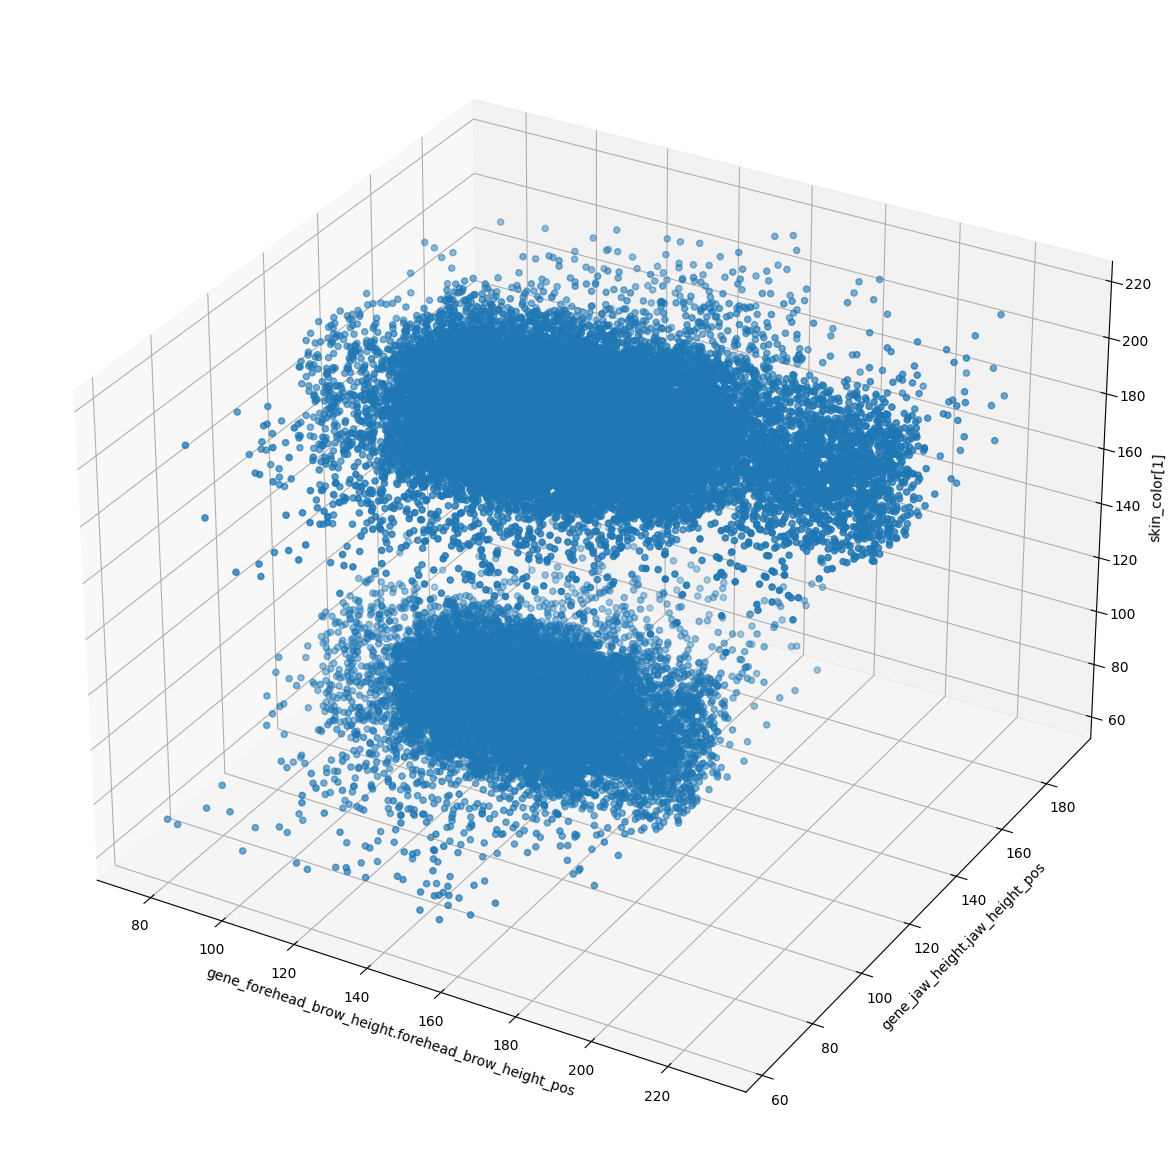

In [34]:
# display 3d distributions of the genes in the test geneset
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

test_geneset_keys = ["gene_forehead_brow_height.forehead_brow_height_pos", "gene_jaw_height.jaw_height_pos", "skin_color[1]"]
X_test_geneset = np.stack([g.asarray(test_geneset_keys) for g in test_geneset_dataset])

# display 3d distributions of the genes in the test geneset
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_geneset[:, 0], X_test_geneset[:, 1], X_test_geneset[:, 2])
ax.set_xlabel(test_geneset_keys[0])
ax.set_ylabel(test_geneset_keys[1])
ax.set_zlabel(test_geneset_keys[2])
plt.show()

In [15]:


gene2dnas = defaultdict(list)
for gene in common_genes:
    gene_min = -255 if gene.split(".")[0] in Genes.model_fields and Genes.model_fields[gene.split(".")[0]].annotation == dict[str, int] else 1
    for i in range(gene_min, 256, 10):
        dna = deepcopy(dataset_dna_template)
        dna[gene] = i
        gene2dnas[gene].append(dna)

In [17]:
save_dir = Path(__name__).resolve().parents[2] / 'data' / 'dnas_2024_04_07'
for gene, dnas in gene2dnas.items():
    gene_dir = save_dir / gene
    gene_dir.mkdir(exist_ok=False, parents=True)
    for i, dna in enumerate(dnas):
        ck_string = Genes(**Genes.unflatten(dna)).to_ck_string()
        dna_fname = f"{i+1}.txt"
        with open(gene_dir / dna_fname, "w") as f:
            f.write(ck_string)
    gene2dnas[gene] = dnas

In [ ]:
# dispaly hisograms for each common gene 
import matplotlib.pyplot as plt
for i, gene in enumerate(common_genes):
    plt.hist(genes_vectorized[:, i])
    plt.title(f"{gene}")
    plt.show()

In [ ]:
import random 
from collections import defaultdict

def create_template_from_genes(genes_list: list[Genes]):
    flattened_dna = [dna.flatten() for dna in genes_list]
    temmplate = defaultdict(list)
    for dna in flattened_dna:
        for key, val in dna.items():
            temmplate[key].append(val)
    avg_template = {key: int(np.mean(val)) for key, val in temmplate.items()}
    return avg_template

random.seed(40)
random.shuffle(genes)
dataset_dna_template = create_template_from_genes(genes)

In [ ]:
# get random image, and gene vector
import random 
import matplotlib.pyplot as plt 

random.seed(114) # is needed to default attributes that are not present in vetorized genes
random_idx = random.randint(0, len(test_images))
image = test_images[random_idx]
gene_vector = Y_test[random_idx]

plt.imshow(image)
plt.show()
# with open(DATA_DIR / "tmp_dna.txt", "w") as f:
#     f.write(Genes.from_array(gene_vector, list(common_genes), dataset_dna_template).to_ck_string())

In [ ]:
from utils.dataset import ProcessedDataset

dataset = ProcessedDataset(Path("/Users/czyjtu/dev/prompt2avatar/data/dataset_2024_04_07_embeddings"))

In [60]:
dataset.paths

array(['/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/0_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10000_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10001_resized.png',
       ...,
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/999_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/99_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/9_resized.png'],
      dtype='<U114')

In [62]:
dnas = [open(path.replace("faces_resized", "dna").replace("png", "txt").replace("_resized", ""), "r").read() for path in dataset.paths]

In [63]:
# np.save("/Users/czyjtu/dev/prompt2avatar/data/test_geneset_embeddings/dnas.npy", dnas)

In [ ]:
i = 100
plt.imshow(dataset.alligned_images[i])
path = Path(dataset.paths[i])
plt.show()
plt.imshow(plt.imread("../../" + dataset.paths[i]))

In [ ]:
path.resolve()

## resize images

In [6]:
import os
from PIL import Image
from tqdm import tqdm
from pathlib import Path 

def resize_image(image_path, max_dimension, out_dir):
    # Open the image
    img = Image.open(image_path)
    
    # Convert the image to RGB mode
    rgb_img = img.convert("RGB")
    
    # Resize the image while preserving aspect ratio
    width, height = rgb_img.size
    if width > height:
        new_width = max_dimension
        new_height = int(height * (max_dimension / width))
    else:
        new_width = int(width * (max_dimension / height))
        new_height = max_dimension
    
    resized_img = rgb_img.resize((new_width, new_height))
    
    # Save the resized image with the same name in the same directory
    directory, filename = os.path.split(image_path)
    filename, ext = os.path.splitext(filename)
    new_filename = os.path.join(out_dir, f"{filename}{ext}")
    resized_img.save(new_filename)
    # print(f"Resized image saved as: {new_filename}")

# Example usage
# image_path = DATA_DIR / "0.png"  # Replace with the path to your image
# max_dimension = 430
# resize_image(image_path, max_dimension)

In [8]:
for path in tqdm(sorted(list(Path("/Users/czyjtu/dev/MP2023/results_medium_geneset").rglob("*.png")))):
    resize_image(path, 430, "/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/medium_geneset/faces_resized")

100%|██████████| 30332/30332 [43:39<00:00, 11.58it/s] 
